# Regression and Ensemble Methods: Appliances Energy Prediction

Regression on household energy consumption data: linear regression, decision tree and random forest compared with 5-fold cross-validation, followed by a gradient boosting model.

*Coursework - BSc in Applied Data Science, Universitat Oberta de Catalunya (UOC), Machine Learning course. Narrative and analysis cells are in Spanish.*

## 1. Loading and exploring the data

The [Appliances Energy Prediction dataset](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction) (UCI Machine Learning Repository) contains 10-minute sensor readings from a low-energy house; the target is appliance energy consumption.

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv -O energydata_complete.csv
import pandas as pd
df = pd.read_csv('energydata_complete.csv')
print(df.head())

--2024-04-18 15:26:07--  https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘energydata_complete.csv’

energydata_complete     [               <=>  ]  11.42M   142KB/s    in 58s     

2024-04-18 15:27:05 (203 KB/s) - ‘energydata_complete.csv’ saved [11979363]

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.33333

### Attributes, missing values and value ranges

In [ ]:
import pandas as pd

# Cargamos los datos:
df = pd.read_csv('energydata_complete.csv')

# Mostramos información básica, incluyendo la cantidad de valores no nulos por columna
print(df.info())

# Mostramos las estadísticas descriptivas
print(df.describe())

# Verificamos la presencia de valores nulos y su eliminación
print(df.isnull().sum())
df_clean = df.dropna()

# Verificamos para asegurar que fueron eliminados
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

* ¿En qué rango se mueven los descriptores?

  Para las variables que corresponden a las Temperaturas internas (T1 a T9): Varían desde un mínimo de aproximadamente 14.89°C hasta un máximo de 29.86°C.

  Para las variable correspondientes a Humedades internas (RH_1 a RH_9): Los valores oscilan entre el 20.46% y el 63.36%.

  Para las variable correspondiente a Temperatura externa (T_out): Varía desde -5°C hasta 26.1°C.

  Para la variable correspondiente a Humedad externa (RH_out): Varía entre el 24% y el 100%, lo cual es un rango muy amplio e indica diversas condiciones climáticas.

  Velocidad del viento (Windspeed): De 0 a 14 m/s.

  Visibilidad (Visibility): De 1 a 66 km.
  
  Para el consumo de energía de las lámparas de la casa varía de 0 a 70 Wh.

  Para las variables aleatorias ('rv1' y 'rv2'): un rango de aproximadamente 0.005 a 50.

* ¿Y la variable objetivo?

  Para la variable objetivo, Electrodomésticos, entre 10 y 1080 vatios-hora.


### Plotting descriptors against the target

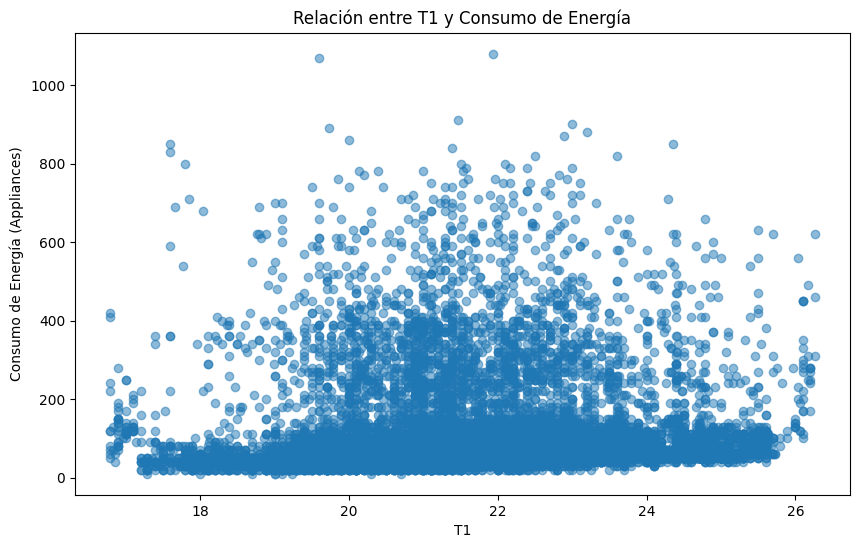

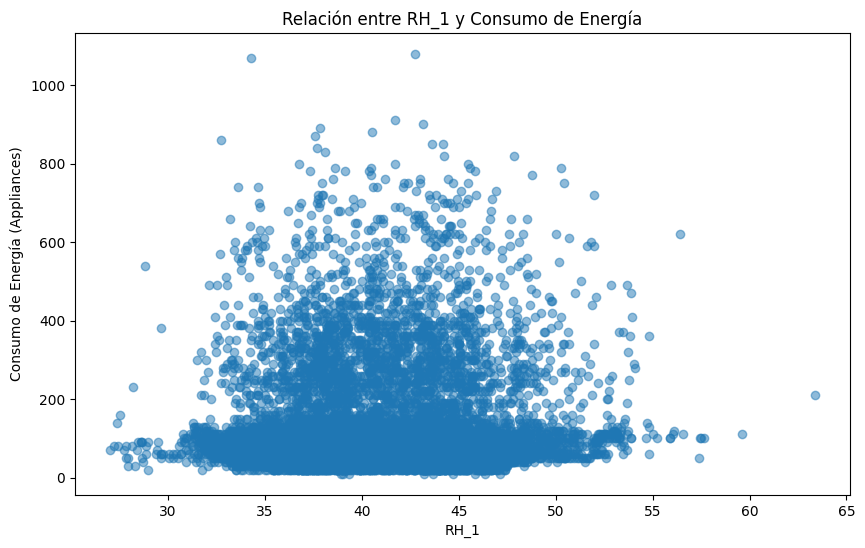

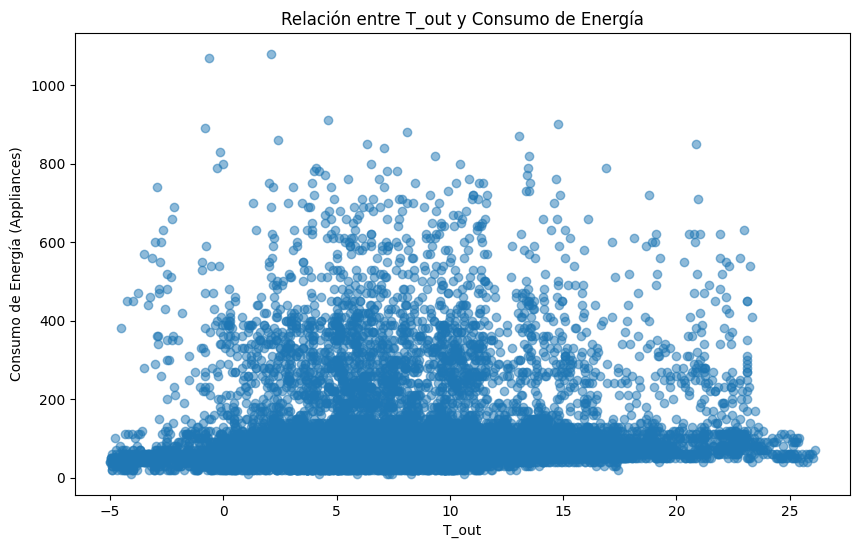

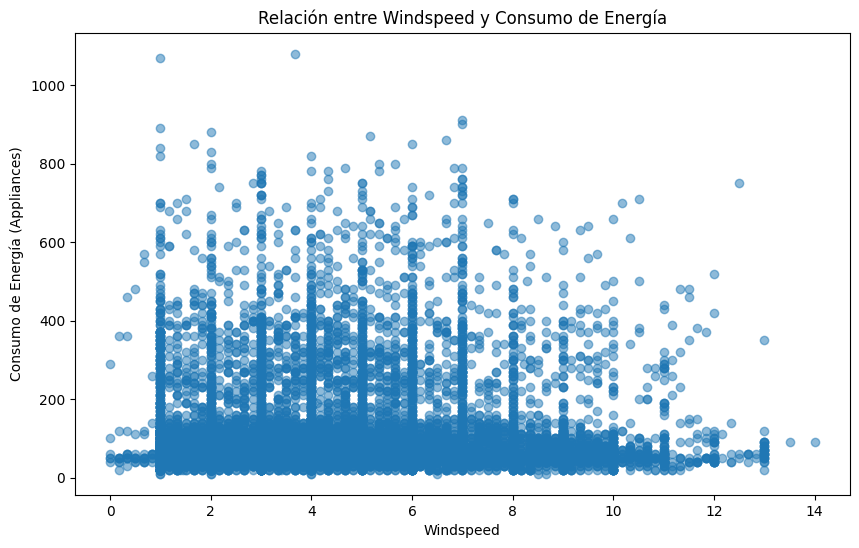

In [ ]:
import matplotlib.pyplot as plt
# Dividimos las variables descriptivas y la variable objetivo
X = df.drop('Appliances', axis=1)
y = df['Appliances']


# Función para crear gráficos
def plot_feature_vs_target(feature):
    plt.figure(figsize=(10, 6))
    plt.scatter(df[feature], y, alpha=0.5)
    plt.title(f'Relación entre {feature} y Consumo de Energía')
    plt.xlabel(feature)
    plt.ylabel('Consumo de Energía (Appliances)')
    plt.show()

# Ejemplos gráficos
plot_feature_vs_target('T1')  # Temperatura en la cocina
plot_feature_vs_target('RH_1')  # Humedad en la cocina
plot_feature_vs_target('T_out')  # Temperatura exterior
plot_feature_vs_target('Windspeed')  # Velocidad del viento


* ¿Observas alguna relación entre los descriptores y la variable objetivo?

  La mayoría de las observaciones se encuentran entre los intervalos 0 a 200 de
  del eje Y, los cuales representan a algunos de los descriptores; pero, aparentemente no hay suficiente correlación entre cada descriptor y la variable objetivo.

* ¿Es lineal esta relación o no?

  No

* ¿Qué consecuencias tiene esto?

  La falta de relación lineal directa implica que la posible correlación sea entre varios descriptores y la variable objetivo.


### Min-max normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Eliminamos la columna de fecha del conjunto de descriptores
X = df.drop(['date'], axis=1)

# Creamos una instancia de MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Ajustamos el escalador solo a los descriptores y transformamos
X_scaled = scaler_X.fit_transform(X)

# Escalamos la variable objetivo 'y'
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))


# Opción para convertir de nuevo a la escala original
#X_unscaled = scaler_X.inverse_transform(X_scaled)
#y_unscaled = scaler_y.inverse_transform(y_scaled)


In [ ]:
# Convertimos los datos escalados a DataFrames para facilitar la descripción de los mismos
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
y_scaled_df = pd.DataFrame(y_scaled, columns=['Appliances'])

# Descripción de los datos escalados para verificar el rango
X_scaled_description = X_scaled_df.describe()
y_scaled_description = y_scaled_df.describe()

print(X_scaled_description)
print(y_scaled_description)


         Appliances        lights            T1          RH_1            T2  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean       0.081958      0.054312      0.517061      0.364271      0.308303   
std        0.095818      0.113371      0.169595      0.109512      0.159412   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.037383      0.000000      0.419219      0.283735      0.195542   
50%        0.046729      0.000000      0.507920      0.347675      0.283499   
75%        0.084112      0.000000      0.613516      0.441519      0.392537   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

               RH_2            T3          RH_3            T4          RH_4  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean       0.561170      0.421038      0.489601      0.518499      0.485143   
std        0.114438      0.166676      0.152107    

### Train/test split

In [ ]:
from sklearn.model_selection import train_test_split


# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)




## 2. Comparing regression models

### Linear regression, decision tree and random forest

Para cada uno de los modelos, calculamos y almacenamos tres métricas de error diferentes:

* *MAE (Error Absoluto Medio)*: Representa la media de los errores absolutos entre las predicciones y los valores verdaderos.
* *MSE (Error Cuadrático Medio)*: Es la media de los errores cuadrados entre las predicciones y los valores verdaderos.
* *RMSE (Raíz del Error Cuadrático Medio)*: Es la raíz cuadrada del MSE y proporciona una medida de error en las mismas unidades que la variable objetivo.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Preparamos el método de validación cruzada
cv = KFold(n_splits=5, random_state=1, shuffle=True)

# Lista para almacenar los modelos
models = []
models.append(('Regresión lineal', LinearRegression()))
models.append(('DecisionTree', DecisionTreeRegressor(random_state=1)))
models.append(('RandomForest', RandomForestRegressor(random_state=1)))

# Diccionario para almacenar las métricas de cada modelo
metrics = { 'MAE': [], 'MSE': [], 'RMSE': [] }

# Bucle para evaluar cada modelo
for name, model in models:
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train.ravel(), scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
    cv_score_mean = np.mean(np.abs(cv_scores))

    # Entrenamos el modelo con todos los datos de entrenamiento
    model.fit(X_train, y_train.ravel())

    # Realizamos predicciones en el conjunto de prueba
    predictions = model.predict(X_test)

    # Calculamos métricas
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    # Almacenamos métricas
    metrics['MAE'].append(mae)
    metrics['MSE'].append(mse)
    metrics['RMSE'].append(rmse)

    # Imprimimos resultados
    print(f"Modelo: {name}")
    print(f"Validación Cruzada - MSE: {cv_score_mean}")
    print(f"Conjunto de Test - MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
    print(f"Predicciones vs Valores Reales - Top 5:")
    print(np.column_stack((predictions[:5], y_test[:5])))
    print("-" * 80)



Modelo: LR
Validación Cruzada - MSE: 2.896359816868448e-29
Conjunto de Test - MAE: 1.6249336948659091e-15, MSE: 2.669931978200698e-30, RMSE: 1.633992649371685e-15
Predicciones vs Valores Reales - Top 5:
[[0.02803738 0.02803738]
 [0.07476636 0.07476636]
 [0.03738318 0.03738318]
 [0.03738318 0.03738318]
 [0.05607477 0.05607477]]
--------------------------------------------------------------------------------
Modelo: DTR
Validación Cruzada - MSE: 7.658083074573228e-06
Conjunto de Test - MAE: 1.1839111215070463e-05, MSE: 1.9916261855735764e-07, RMSE: 0.00044627639256110966
Predicciones vs Valores Reales - Top 5:
[[0.02803738 0.02803738]
 [0.07476636 0.07476636]
 [0.03738318 0.03738318]
 [0.03738318 0.03738318]
 [0.05607477 0.05607477]]
--------------------------------------------------------------------------------
Modelo: RFR
Validación Cruzada - MSE: 1.9649503912480214e-06
Conjunto de Test - MAE: 1.1247155653911351e-05, MSE: 1.0462454936414114e-07, RMSE: 0.00032345718320071537
Prediccion

### Metric comparison: 5-fold cross-validation and test set

Creamos un DataFrame de pandas (`metrics_df`) para almacenar y visualizar estas métricas de error para cada modelo, lo cual nos permitirá comparar fácilmente su rendimiento.


In [ ]:
# Comparación de métricas de la validación cruzada 5-fold
print("Comparación de métricas de la validación cruzada 5-fold")
model_names = [name for name, _ in models]
cv_means = [-np.mean(cross_val_score(model, X_train, y_train.ravel(), scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)) for _, model in models]
cv_means = np.sqrt(np.abs(cv_means))  # Convertir a RMSE
for name, cv_mean in zip(model_names, cv_means):
    print(f"{name} RMSE: {cv_mean}")

Comparación de métricas de la validación cruzada 5-fold
LR RMSE: 5.3817839206609256e-15
DTR RMSE: 0.0027673241722959074
RFR RMSE: 0.0014017668819201077


In [ ]:
# Comparación de métricas en el conjunto de prueba
print("\nComparación de métricas en el conjunto de prueba")
for name, mae, mse, rmse in zip(model_names, metrics['MAE'], metrics['MSE'], metrics['RMSE']):
    print(f"{name} - MAE: {mae}, MSE: {mse}, RMSE: {rmse}")


Comparación de métricas en el conjunto de prueba
LR - MAE: 1.6249336948659091e-15, MSE: 2.669931978200698e-30, RMSE: 1.633992649371685e-15
DTR - MAE: 1.1839111215070463e-05, MSE: 1.9916261855735764e-07, RMSE: 0.00044627639256110966
RFR - MAE: 1.1247155653911351e-05, MSE: 1.0462454936414114e-07, RMSE: 0.00032345718320071537


### Sample predictions

In [ ]:
# Print de las predicciones vs los valores reales
print("\nPredicciones vs Valores Reales - Modelo Regresión lineal")
lr_predictions = models[0][1].predict(X_test)
for predicted, actual in zip(lr_predictions[:5], y_test[:5].ravel()):
    print(f"Predicho: {predicted}, Real: {actual}")


Predicciones vs Valores Reales - Modelo LR
Predicho: 0.02803738317757164, Real: 0.028037383177570097
Predicho: 0.07476635514018852, Real: 0.07476635514018692
Predicho: 0.037383177570094905, Real: 0.03738317757009346
Predicho: 0.03738317757009494, Real: 0.03738317757009346
Predicho: 0.05607476635514175, Real: 0.05607476635514019


## 3. Gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Definimos el modelo de boosting
boosting_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=1)

# Aplicamos k-fold cross-validation
cv_scores = cross_val_score(boosting_model, X_train, y_train.ravel(), scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)

# Calculamos y mostrar el RMSE de la validación cruzada
cv_rmse = np.sqrt(np.abs(cv_scores))
print(f"Validación Cruzada - RMSE: {np.mean(cv_rmse)}")

# Entrenamos el modelo con todo el conjunto de entrenamiento
boosting_model.fit(X_train, y_train.ravel())

# Realizamos predicciones en el conjunto de prueba
boosting_predictions = boosting_model.predict(X_test)

# Calculamos métricas
mae = mean_absolute_error(y_test, boosting_predictions)
mse = mean_squared_error(y_test, boosting_predictions)
rmse = np.sqrt(mse)

Validación Cruzada - RMSE: 0.0004977221343824568


### Test-set error

In [ ]:
# Imprimimos resultados del conjunto de prueba
print(f"Conjunto de Test - MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

Conjunto de Test - MAE: 5.877990725672173e-05, MSE: 9.406622225994981e-08, RMSE: 0.0003067021719191923


## 4. Results analysis

* ¿Existe alguna mejora en base a los métodos estudiados en esta parte de la práctica?
* Si es así, ¿es una mejora general? ¿Por qué?

Dado que los errores de predicción son muy pequeños, podemos inferir que el modelo de boosting está funcionando excepcionalmente bien para este conjunto de datos. La mejora parece ser general, ya que tanto el proceso de validación cruzada como los resultados en el conjunto de prueba muestran errores muy bajos.

* Según este comportamiento, ¿qué conclusión puedes sacar sobre los datos en sí?
La alineación de las predicciones con los valores reales y los bajos errores nos indican que los datos son bastante predecibles y que el modelo ha capturado muy bien las relaciones subyacentes. Esto podría sugerir que los datos tienen un ruido muy bajo y que las características son buenos predictores del objetivo.

* *Qué posibles mejoras se te ocurrirían para conseguir mejores resultados?


Por ejemplo, el ajuste de Hiperparámetros. Utilizar búsqueda en cuadrícula  o GridSearchCV; o búsqueda aleatoria o RandomizedSearchCV; para encontrar los mejores hiperparámetros para el modelo de boosting.

Feature Engineering. Se podría experimentar con la creación de nuevas características o la selección de características para ver si el rendimiento puede mejorarse.

Probar con algoritmos de aprendizaje automático más avanzados o recientes, como XGBoost, LightGBM o redes neuronales profundas, que podrían capturar complejidades adicionales.

Combinar diferentes modelos predictivos en un ensamble para ver si el rendimiento mejora. Esto podría hacerse mediante stacking o una votación de modelos.

Por último, la validación Cruzada Anidada. Asegurarnos de que el proceso de selección del modelo y el ajuste de hiperparámetros no estén sesgados mediante la implementación de una validación cruzada anidada.


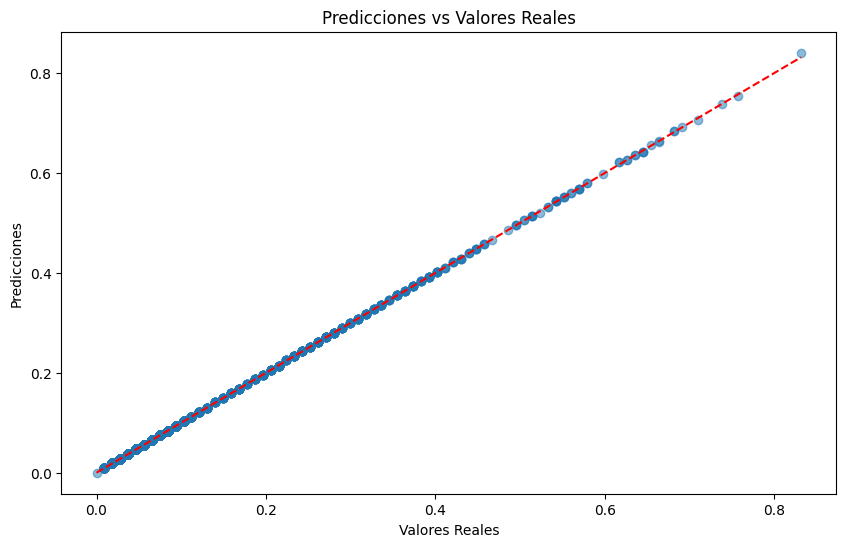

In [ ]:
# Visualizamos el error
plt.figure(figsize=(10, 6))
plt.scatter(y_test, boosting_predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.show()